# Imports

In [1]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report

from scipy.sparse import hstack
import lightgbm as lgb
np.random.seed(42)

#  Load Dataset

In [2]:
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")


# ================================================================
# EXPLORATORY DATA ANALYSIS
# ================================================================

#  Basic Shape & Info 

In [3]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\n--- Column Data Types ---")
print(train.dtypes)
print("\n--- First 5 Rows ---")
train.head()

Train shape: (198000, 15)
Test shape: (102000, 14)

--- Column Data Types ---
created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
label            int64
dtype: object

--- First 5 Rows ---


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


The dataset contains both textual and structured features:
- Text feature: comment
- Reaction features: upvote, downvote
- Emoticon indicators
- Internal platform features (if_1, if_2)
- Sensitive topic indicators
- Timestamp feature (created_date)

In [5]:
print("Missing values in train:")
print(train.isnull().sum()[train.isnull().sum() > 0])
missing_cols = train.isnull().sum()[train.isnull().sum() > 0].index.tolist()

Missing values in train:
race        145423
religion    145423
gender      145423
comment          1
dtype: int64


## Basic Preprocessing
Filling missing comment with empty string and converting disability column to integer.

In [6]:
train['comment'] = train['comment'].fillna("")
test['comment']  = test['comment'].fillna("")

train['disability'] = train['disability'].astype(int)
test['disability']  = test['disability'].astype(int)

---

#  Target Label Distribution 

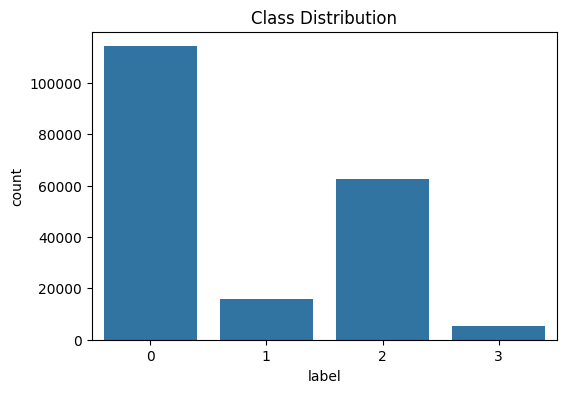

label
0    57.663131
2    31.535354
1     8.039394
3     2.762121
Name: proportion, dtype: float64

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=train)
plt.title("Class Distribution")
plt.show()

train['label'].value_counts(normalize=True) * 100

The dataset is imbalanced, with class 0 being dominant and class 3 being the minority class.
Hence, Macro F1 Score is used to fairly evaluate all classes.

---

#  Numeric Features by Label 

In [8]:
num_features = ['upvote', 'downvote', 'if_1', 'if_2', 'emoticon_1', 'emoticon_2', 'emoticon_3']

print("Numeric feature stats by label:")
print(train.groupby('label')[num_features].mean().round(2))


Numeric feature stats by label:
       upvote  downvote  if_1   if_2  emoticon_1  emoticon_2  emoticon_3
label                                                                   
0        2.40      0.58  1.30   4.86        0.28        0.04        0.11
1        2.85      0.80  8.01  11.87        0.26        0.06        0.15
2        2.97      0.81  1.53  12.21        0.28        0.05        0.14
3        2.04      0.51  1.13  12.62        0.28        0.07        0.13


---

# EDA Summary & Insights 

In [9]:
print(f"Dataset has {train.shape[0]} training and {test.shape[0]} test samples")
print(f"Target has {train['label'].nunique()} classes: {sorted(train['label'].unique())}")
print(f"Columns with missing values: {missing_cols}")
print(f"Label with highest avg upvotes: {train.groupby('label')['upvote'].mean().idxmax()}")
print(f"Label with highest avg if_2: {train.groupby('label')['if_2'].mean().idxmax()}")
print(f"Most common label: {train['label'].value_counts().idxmax()} ({train['label'].value_counts(normalize=True).max()*100:.1f}%)")

Dataset has 198000 training and 102000 test samples
Target has 4 classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Columns with missing values: ['race', 'religion', 'gender', 'comment']
Label with highest avg upvotes: 2
Label with highest avg if_2: 3
Most common label: 0 (57.7%)


Started by looking at the data shape, types and missing values.
race, religion and gender have ~73% missing values - the platform only flags these 
when explicitly mentioned in a comment, so missing just means "not referenced", 
filled with 'none' and ordinally encoded.
comment had 1 missing value, filled with empty string.
if_2 has the highest correlation with label (0.23) - strongest predictor among all structured features.
class 0 is the dominant class (57.6%), class 3 is the minority (2.7%) - hence Macro F1 is used.

---

# Text Cleaning

In [10]:
def clean_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train['comment_clean'] = train['comment'].apply(clean_text)
test['comment_clean'] = test['comment'].apply(clean_text)

---

#  Feature Engineering

In [11]:
for dataset in [train, test]:
    
    dataset['comment_length'] = dataset['comment_clean'].apply(len)
    dataset['word_count'] = dataset['comment_clean'].apply(lambda x: len(x.split()))
    
    dataset['total_emoticons'] = dataset['emoticon_1'] + dataset['emoticon_2'] + dataset['emoticon_3']
    
    dataset['upvote_ratio'] = dataset['upvote'] / (dataset['downvote'] + 1)
    
    dataset['created_date'] = pd.to_datetime(dataset['created_date'])
    dataset['hour'] = dataset['created_date'].dt.hour
    dataset['dayofweek'] = dataset['created_date'].dt.dayofweek
    dataset.drop(columns=['created_date'], inplace=True)
    
    dataset['exclamation_count'] = dataset['comment'].str.count('!')
    dataset['question_count'] = dataset['comment'].str.count(r'\?')



    dataset['score_difference'] = dataset['upvote'] - dataset['downvote']
    dataset['engagement'] = dataset['upvote'] + dataset['downvote']
    dataset['controversy'] = dataset['downvote'] / (dataset['downvote'] + dataset['upvote'] + 0.0001)
    dataset['has_emotion'] = (dataset['total_emoticons'] > 0).astype(int)
    dataset['is_weekend'] = dataset['dayofweek'].isin([5,6]).astype(int)
    dataset['is_sunday'] = (dataset['dayofweek'] == 6).astype(int)

Added a few extra features that I thought might help:
- upvote_ratio to capture how well received a comment is
- total_emoticons combining all 3 emoticon columns
- comment length and word count from cleaned text
- hour and day of week from the post timestamp
- exclamation and question mark counts as rough sentiment signals
- score_difference, engagement, controversy: capture voting patterns
- has_emotion, is_weekend, is_sunday: binary flags for emotion and time

---

# Data Preprocessing Pipeline
Used ColumnTransformer with two separate pipelines:
- Numeric pipeline: StandardScaler to normalize all numerical features
- Categorical pipeline: SimpleImputer to fill missing values with 'none', followed by OrdinalEncoder to convert text categories to numbers
This ensures a clean and consistent preprocessing step before combining with TF-IDF features.

In [12]:
struct_cols = [c for c in train.columns if c not in ['comment', 'comment_clean', 'label', 'post_id']]

numeric_cols = train[struct_cols].select_dtypes(include=['number']).columns.tolist()
categorical_cols = train[struct_cols].select_dtypes(include=['object']).columns.tolist()

print("Numeric cols:", numeric_cols)
print("Categorical cols:", categorical_cols)

Numeric cols: ['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'disability', 'comment_length', 'word_count', 'total_emoticons', 'upvote_ratio', 'hour', 'dayofweek', 'exclamation_count', 'question_count', 'score_difference', 'engagement', 'controversy', 'has_emotion', 'is_weekend', 'is_sunday']
Categorical cols: ['race', 'religion', 'gender']


In [13]:
numeric_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='none')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

X_struct      = preprocessor.fit_transform(train[numeric_cols + categorical_cols])
X_test_struct = preprocessor.transform(test[numeric_cols + categorical_cols])

print("Structured features shape:", X_struct.shape)

Structured features shape: (198000, 25)


---

#  Correlation Analysis 

<Axes: >

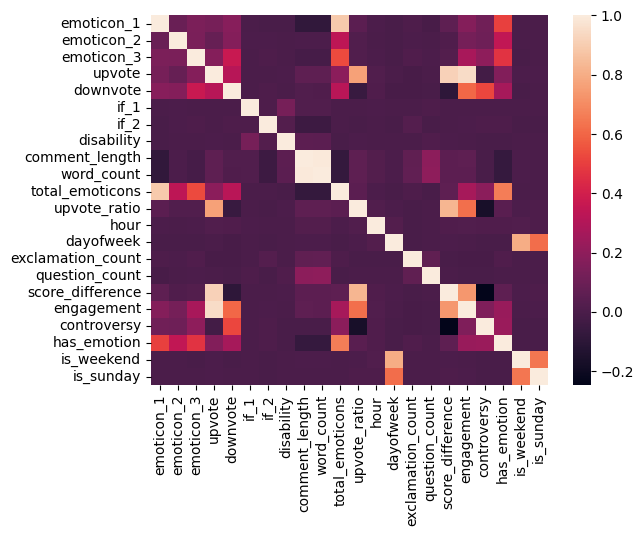

In [14]:
sns.heatmap(train[numeric_cols].corr())

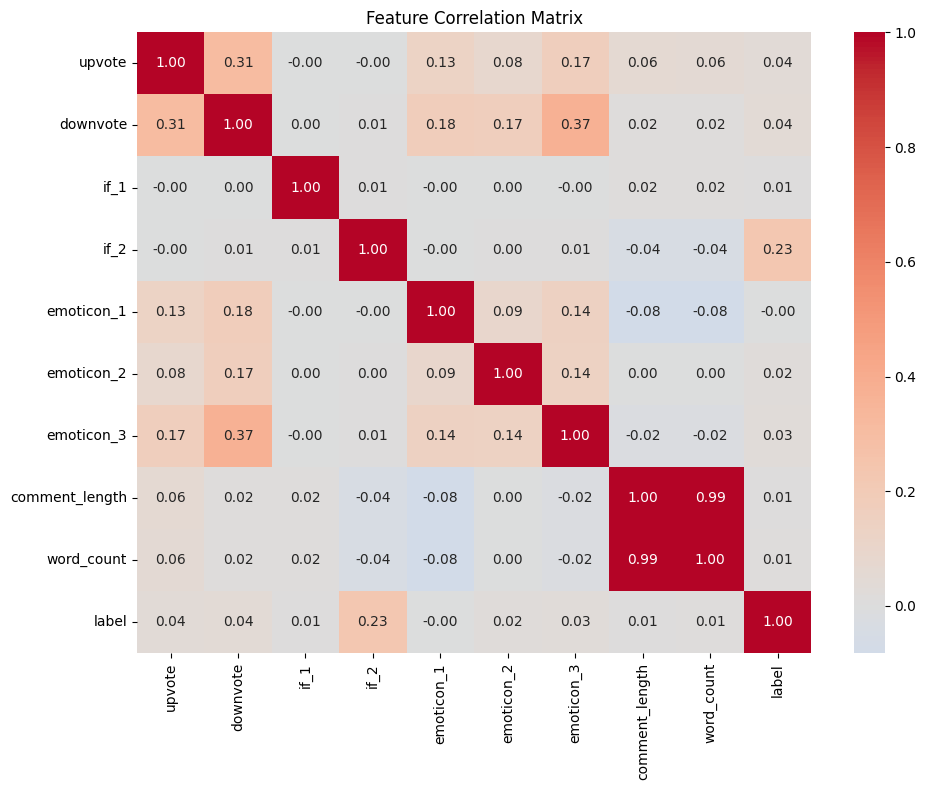


Features most correlated with label:
if_2              0.232902
downvote          0.044908
upvote            0.040181
emoticon_3        0.027273
emoticon_2        0.021597
word_count        0.013221
comment_length    0.010643
if_1              0.007543
emoticon_1        0.003218
Name: label, dtype: float64


In [15]:
corr_cols = ['upvote', 'downvote', 'if_1', 'if_2',
             'emoticon_1', 'emoticon_2', 'emoticon_3',
             'comment_length', 'word_count', 'label']

plt.figure(figsize=(10, 8))
corr_matrix = train[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("\nFeatures most correlated with label:")
print(corr_matrix['label'].drop('label').abs().sort_values(ascending=False))

---

# TF-IDF Vectorization

We convert cleaned text into numerical features using TF-IDF.
Unigrams and bigrams are used to capture contextual information.

### Word TF-IDF

In [16]:
word_vectorizer = TfidfVectorizer(

    stop_words='english',
    
    max_features=50000,
    
    ngram_range=(1,2),
    
    min_df=3,
    
    sublinear_tf=True
)

print("Building WORD TFIDF")

X_word = word_vectorizer.fit_transform(
    train['comment_clean']
)

X_test_word = word_vectorizer.transform(
    test['comment_clean']
)

Building WORD TFIDF


 ### Character TF-IDF

In [17]:
char_vectorizer = TfidfVectorizer(

    analyzer='char',
    
    ngram_range=(3,5),
    
    max_features=10000
)

print("Building CHAR TFIDF")

X_char = char_vectorizer.fit_transform(
    train['comment_clean']
)

X_test_char = char_vectorizer.transform(
    test['comment_clean']
)

Building CHAR TFIDF


Used two TF-IDF vectorizers and combined them:
- Word ngrams (1,2) with 50k features for word/phrase level patterns
- Char ngrams (3,5) with 10k features to handle typos and word variations

### Combine Text Features

In [18]:
X_text = hstack([X_word, X_char])

X_test_text = hstack([X_test_word, X_test_char])

print("Word features:", X_word.shape)
print("Char features:", X_char.shape)
print("Combined:", X_text.shape)

Word features: (198000, 50000)
Char features: (198000, 10000)
Combined: (198000, 60000)


---

# Final Feature Matrix

In [19]:
X_final = hstack([X_text, X_struct])
X_test_final = hstack([X_test_text, X_test_struct])



y = train['label']

print("Total features:", X_final.shape[1])

Total features: 60025


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

X_train, X_val, y_train, y_val = train_test_split(
    X_final,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Hyperparameter Selection
Parameters were selected through manual experimentation:
- num_leaves=64 : Balances model complexity - 31 underfit, 128 overfit slightly
- learning_rate=0.05 : Gives stable convergence alongside early stopping
- Early stopping monitors validation loss to automatically find the optimal number of trees

In [21]:
best_params = {
    'num_leaves': 64,
    'learning_rate': 0.05,
}

## Three models were implemented for comparison:
 1. Logistic Regression
 2. Linear SVM
 3. LightGBM

# Model 1 - LightGBM

In [22]:
print("Training LightGBM")

lgb_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=4,
    min_child_samples=20,
    n_estimators=1000,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=42,
    **best_params
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='multi_logloss',
    callbacks=[
        lgb.early_stopping(100),
        lgb.log_evaluation(100)
    ]
)

lgb_val_preds = lgb_model.predict(X_val)
lgb_f1 = f1_score(y_val, lgb_val_preds, average='macro')
print("LightGBM F1:", lgb_f1)

print(classification_report(y_val, lgb_val_preds))

best_iter = lgb_model.best_iteration_ if lgb_model.best_iteration_ > 0 else 1000
print("Best trees:", best_iter)

Training LightGBM
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 45.984390 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3429367
[LightGBM] [Info] Number of data points in the train set: 158400, number of used fea

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
LightGBM F1: 0.8136501728037382
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.78      0.79      0.79      3183
           2       0.85      0.92      0.89     12488
           3       0.76      0.52      0.62      1094

    accuracy                           0.92     39600
   macro avg       0.84      0.80      0.81     39600
weighted avg       0.92      0.92      0.92     39600

Best trees: 305


The classification report shows per-class precision, recall and F1.
Class 3 has the lowest F1 due to class imbalance.

## Per-class F1 Score - LightGBM

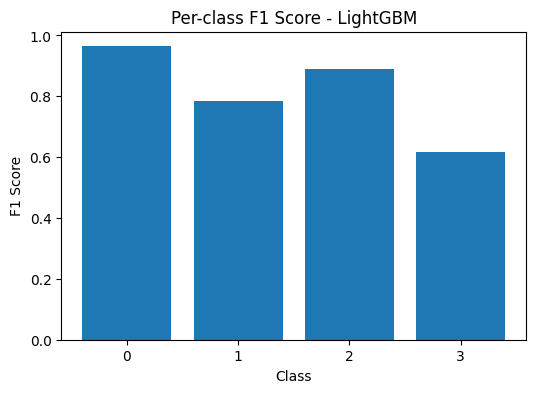

In [23]:
from sklearn.metrics import classification_report
report = classification_report(y_val, lgb_val_preds, output_dict=True)
classes = ['0', '1', '2', '3']
f1_scores = [report[c]['f1-score'] for c in classes]
plt.figure(figsize=(6,4))
plt.bar(classes, f1_scores)
plt.xlabel('Class')
plt.ylabel('F1 Score')
plt.title('Per-class F1 Score - LightGBM')
plt.show()

# Model 2 - Logistic Regression

In [24]:
print("Training Logistic Regression")
log_model = LogisticRegression(max_iter=2000, n_jobs=-1)
log_model.fit(X_train, y_train)
log_val_preds = log_model.predict(X_val)
log_f1 = f1_score(y_val, log_val_preds, average='macro')
print("Logistic Regression F1:", log_f1)

Training Logistic Regression
Logistic Regression F1: 0.7974666079056542


#  Model 3 - Linear SVM

In [25]:
print("Training SVM")
svm_model = CalibratedClassifierCV(LinearSVC())
svm_model.fit(X_train, y_train)
svm_val_preds = svm_model.predict(X_val)
svm_f1 = f1_score(y_val, svm_val_preds, average='macro')
print("SVM F1:", svm_f1)

Training SVM
SVM F1: 0.6592914812393942


#  Comparing Models

In [26]:
print("\nModel Comparison")

print("Logistic F1:", log_f1)
print("LightGBM F1:", lgb_f1)
print("SVM F1:", svm_f1)


Model Comparison
Logistic F1: 0.7974666079056542
LightGBM F1: 0.8136501728037382
SVM F1: 0.6592914812393942


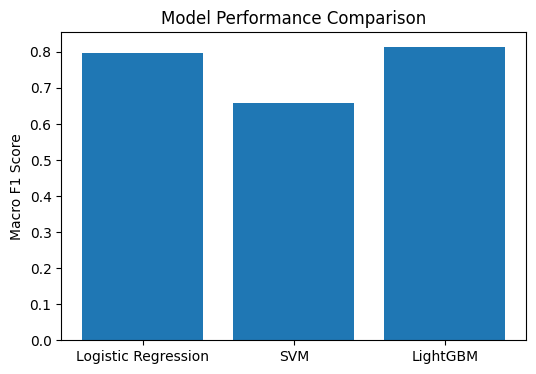

In [27]:
model_scores = {
    "Logistic Regression": log_f1,
    "SVM": svm_f1,
    "LightGBM": lgb_f1
}

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(model_scores.keys(), model_scores.values())

plt.ylabel("Macro F1 Score")
plt.title("Model Performance Comparison")

plt.show()

## LightGBM Confusion Matrix

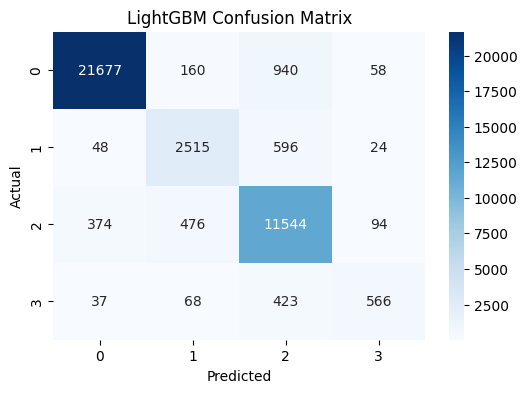

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, lgb_val_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

The confusion matrix shows the model performs best on class 0 (majority class).
Class 3 has the most misclassifications due to being the minority class - 
this is why Macro F1 is a better metric than accuracy here.

#  Picking the best model

In [29]:
models = {
    "logistic": log_f1,
    "lightgbm": lgb_f1,
    "svm": svm_f1
}

best_model = max(models, key=models.get)
print("\nBest Model:", best_model)


Best Model: lightgbm


# Train Best Model on Full Data

In [30]:
print("Training final model on full data with best_iter:", best_iter)

if best_model == "logistic":
    print("Using Logistic Regression retraining on full data")
    final_model = LogisticRegression(max_iter=2000, n_jobs=-1)
    final_model.fit(X_final, y)

elif best_model == "svm":
    print("Using SVM retraining on full data")
    final_model = CalibratedClassifierCV(LinearSVC())
    final_model.fit(X_final, y)

elif best_model == "lightgbm":
    print(f"Using LightGBM retraining on full data with {best_iter} trees")

    final_model = lgb.LGBMClassifier(
        objective='multiclass',
        num_class=4,
        n_estimators= best_iter,
        min_child_samples=20,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=5,
        random_state=42,
        **best_params
    )
    final_model.fit(X_final, y)

test_preds = final_model.predict(X_test_final)
print(np.unique(test_preds))

Training final model on full data with best_iter: 305
Using LightGBM retraining on full data with 305 trees
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 82.630900 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, yo

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[0 1 2 3]


# Submission

In [31]:
sample = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

sample['label'] = test_preds

sample.to_csv("submission.csv", index=False)

print("Submission ready")

Submission ready


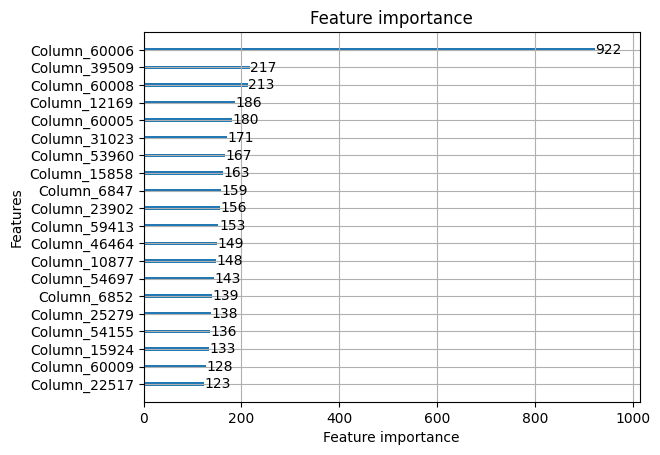

In [32]:
if best_model == "lightgbm":
    lgb.plot_importance(final_model, max_num_features=20)
    plt.show()

# ================================================================================================================================
# End of notebook
# ================================================================================================================================

## Appendix for milestones

# - Milestone 1

In [33]:
# import pandas as pd
# import numpy as np

# train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
# test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")


# # ------------------------------------------------
# # 3. Shape of Training Dataset
# # ------------------------------------------------
# print("shape of training dataset :", train.shape)



# # ------------------------------------------------
# # 4. Number of Columns in Test Dataset
# # ------------------------------------------------
# print("Number of colums in test dataset :", test.shape[1])



# # ------------------------------------------------
# # 5. Object Data Type Columns Count
# # ------------------------------------------------
# obj_cols = train.select_dtypes(include=['object'])
# print("Number of object type colums in training dataset :", obj_cols.shape[1])



# # ------------------------------------------------
# # 6. Numerical Columns Count
# # ------------------------------------------------
# num_cols = train.select_dtypes(include=['number'])
# print("Number of numerical colums present in training dataset :", num_cols.shape[1])


# # ------------------------------------------------
# # 7. Boolean Columns
# # ------------------------------------------------
# bool_cols = train.select_dtypes(include=['bool'])
# print("Boolean columns:", bool_cols.columns.tolist())



# # ------------------------------------------------
# # 8. Columns with Missing Values
# # ------------------------------------------------
# missing_columns = train.columns[train.isnull().any()]
# print("Columns with missing values:", missing_columns.tolist())



# # ------------------------------------------------
# # 9. Distinct Target Classes
# # ------------------------------------------------
# print("Number of distinct target classes:", train['label'].nunique())



# # ------------------------------------------------
# # 10. Percentage of Label 0
# # ------------------------------------------------
# percentage_label_0 = (train['label'] == 0).mean() * 100
# print("Percentage of label 0:", percentage_label_0)


# # ------------------------------------------------
# # 11. Median Upvotes
# # ------------------------------------------------
# print("Median number of upvotes:", train['upvote'].median())


# # ------------------------------------------------
# # 12. Numerical Feature with Largest Maximum Value
# # ------------------------------------------------
# max_values = num_cols.max()
# print("Feature with largest maximum value:", max_values.idxmax())

# # ------------------------------------------------
# # 13. Minimum Value of if_2
# # ------------------------------------------------
# print("Minimum value of if_2:", train['if_2'].min())

# - Milestone 2

In [34]:
# import pandas as pd
# import numpy as np
# import string
# from sklearn.feature_extraction.text import TfidfVectorizer

# train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

# # ------------------------------------------------
# # 1 Missingness Check (NaN + empty strings)
# # ------------------------------------------------

# nan_count = train['comment'].isna().sum()
# empty_or_space = train['comment'].fillna('').str.strip().eq('').sum()

# print("NaN comments:", nan_count)
# print("Empty or whitespace-only comments:", empty_or_space)

# # ------------------------------------------------
# # 2 Most Frequent Month
# # ------------------------------------------------

# train['created_date'] = pd.to_datetime(train['created_date'])
# most_common_month = train['created_date'].dt.month_name().str.lower().value_counts().idxmax()
# print("Most frequent month:", most_common_month)

# # ------------------------------------------------
# # 3 total_emoticons Feature
# # ------------------------------------------------

# train['total_emoticons'] = (
#     train['emoticon_1'] +
#     train['emoticon_2'] +
#     train['emoticon_3']
# )

# print("Maximum total_emoticons:", train['total_emoticons'].max())

# # ------------------------------------------------
# # 4 Median Character Length (label == 3)
# # ------------------------------------------------

# train['comment'] = train['comment'].fillna('')
# train['char_length'] = train['comment'].apply(len)

# median_length = train[train['label'] == 3]['char_length'].median()
# print("Median character length (label=3):", median_length)

# # ------------------------------------------------
# # 5 Min-Max Scaling for upvote (value = 10)
# # ------------------------------------------------

# min_upvote = train['upvote'].min()
# max_upvote = train['upvote'].max()
# scaled_value = (10 - min_upvote) / (max_upvote - min_upvote)

# print("Scaled value for 10 upvotes:", scaled_value)

# # ------------------------------------------------
# # 6 Average Word Count (label == 1)
# # ------------------------------------------------

# train['word_count'] = train['comment'].apply(lambda x: len(str(x).split()))
# avg_word_count = train[train['label'] == 1]['word_count'].mean()

# print("Average word count (label=1):", round(avg_word_count, 2))

# # ------------------------------------------------
# # 7 Count 'Trump' (Case-Insensitive)
# # ------------------------------------------------

# trump_count = train['comment'].str.contains("Trump", case=False, na=False).sum()
# print("Comments containing 'Trump':", trump_count)

# # ------------------------------------------------
# # 8 First Row Cleaning + Stopword Removal
# # ------------------------------------------------

# stop_words = ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 'for', 'with', 
#               'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', 'was', 
#               'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 
#               'they', 'them', 'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 
#               'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your']

# text = train.loc[0, 'comment']
# text = text.translate(str.maketrans('', '', string.punctuation))
# tokens = text.lower().split()
# filtered_tokens = [word for word in tokens if word not in stop_words]

# print("Remaining words in first comment:", len(filtered_tokens))

# # ------------------------------------------------
# # 9 Total Unique Tokens (lowercase, whitespace tokenization)
# # ------------------------------------------------

# all_tokens = train['comment'].str.lower().str.split().explode()
# unique_tokens = all_tokens.nunique()

# print("Total unique tokens:", unique_tokens)

# # ------------------------------------------------
# # 10 TF-IDF Feature Count
# # ------------------------------------------------

# vectorizer = TfidfVectorizer(
#     stop_words='english',
#     min_df=5,
#     ngram_range=(1,2)
# )

# X_tfidf = vectorizer.fit_transform(train['comment'])
# print("Number of TF-IDF features:", X_tfidf.shape[1])

# - Milestone 3

In [35]:
# # ==========================================
# # MILESTONE 3 COMPLETE SOLUTION
# # ==========================================

# import pandas as pd
# import numpy as np

# from sklearn.model_selection import train_test_split
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import f1_score
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from scipy import sparse

# # -------------------------------
# # Load Data
# # -------------------------------

# df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

# X = df.drop("label", axis=1)
# y = df["label"]

# # -------------------------------
# # 1 Train Validation Split
# # -------------------------------

# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# print("a + c =", X_train.shape[0] + X_val.shape[0])

# # -------------------------------
# # 2 Most Frequent Month in X_train
# # -------------------------------

# X_train['created_date'] = pd.to_datetime(X_train['created_date'])
# most_common_month = (
#     X_train['created_date']
#     .dt.month_name()
#     .str.lower()
#     .value_counts()
#     .idxmax()
# )

# print("Most frequent month in X_train:", most_common_month)

# # -------------------------------
# # 3 Impute categorical + OneHot
# # -------------------------------

# cat_cols = ['religion', 'gender', 'race']

# X_train_cat = X_train[cat_cols].fillna("none")
# X_val_cat = X_val[cat_cols].fillna("none")

# ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# X_train_cat_enc = ohe.fit_transform(X_train_cat)
# X_val_cat_enc = ohe.transform(X_val_cat)

# X_train_cat_df = pd.DataFrame(
#     X_train_cat_enc,
#     columns=ohe.get_feature_names_out(cat_cols),
#     index=X_train.index
# )

# print("b value after encoding:", X_train_cat_df.shape[1])

# # -------------------------------
# # 4 CountVectorizer sum for index 1
# # -------------------------------

# cv = CountVectorizer()

# X_train_comment = cv.fit_transform(X_train['comment'].fillna(""))
# X_val_comment = cv.transform(X_val['comment'].fillna(""))

# print("Sum of counts at index 1:",
#       X_train_comment[1].sum())

# # -------------------------------
# # 5 Disability conversion
# # -------------------------------

# X_train['disability'] = X_train['disability'].astype(int)
# X_val['disability'] = X_val['disability'].astype(int)

# total_disability_sum = (
#     X_train['disability'].sum() +
#     X_val['disability'].sum()
# )

# print("Total disability sum:", total_disability_sum)

# # -------------------------------
# # 6 StandardScaler numeric features
# # -------------------------------

# X_train_dt = X_train.copy()
# X_val_dt = X_val.copy()

# X_train_dt['created_date'] = pd.to_datetime(X_train_dt['created_date'])
# X_val_dt['created_date'] = pd.to_datetime(X_val_dt['created_date'])

# # extract day month year
# for df_ in [X_train_dt, X_val_dt]:
#     df_['day'] = df_['created_date'].dt.day
#     df_['month'] = df_['created_date'].dt.month
#     df_['year'] = df_['created_date'].dt.year
#     df_.drop('created_date', axis=1, inplace=True)

# numeric_cols = X_train_dt.select_dtypes(include=['number']).columns

# scaler = StandardScaler()
# scaler.fit(X_train_dt[numeric_cols])

# print("Number of features seen during fit:",
#       scaler.n_features_in_)

# # ======================================================
# # FULL PREPROCESS + MULTINOMIAL NB (FIRST CONFIG)
# # ======================================================

# X_full_train, X_full_val, y_full_train, y_full_val = train_test_split(
#     df.drop("label", axis=1),
#     df["label"],
#     test_size=0.2,
#     random_state=42
# )

# # Impute
# imputer = SimpleImputer(strategy='most_frequent')
# X_full_train = pd.DataFrame(
#     imputer.fit_transform(X_full_train),
#     columns=X.columns
# )
# X_full_val = pd.DataFrame(
#     imputer.transform(X_full_val),
#     columns=X.columns
# )

# # Remove negative values
# num_cols = X_full_train.select_dtypes(include=['number']).columns

# X_full_train[num_cols] = X_full_train[num_cols].abs()
# X_full_val[num_cols] = X_full_val[num_cols].abs()

# # Date features
# for d in [X_full_train, X_full_val]:
#     d['created_date'] = pd.to_datetime(d['created_date'])
#     d['day'] = d['created_date'].dt.day
#     d['month'] = d['created_date'].dt.month
#     d['year'] = d['created_date'].dt.year
#     d.drop('created_date', axis=1, inplace=True)

# # TFIDF
# tfidf = TfidfVectorizer(stop_words='english')

# X_train_text = tfidf.fit_transform(X_full_train['comment'])
# X_val_text = tfidf.transform(X_full_val['comment'])

# # Drop comment before OHE
# X_full_train = X_full_train.drop('comment', axis=1)
# X_full_val = X_full_val.drop('comment', axis=1)

# # OneHot categorical
# cat_features = X_full_train.select_dtypes(include=['object']).columns

# ohe2 = OneHotEncoder(handle_unknown='ignore')

# X_train_cat2 = ohe2.fit_transform(X_full_train[cat_features])
# X_val_cat2 = ohe2.transform(X_full_val[cat_features])

# # Numeric features
# num_features = X_full_train.select_dtypes(include=['number']).columns

# X_train_num = sparse.csr_matrix(X_full_train[num_features])
# X_val_num = sparse.csr_matrix(X_full_val[num_features])

# # Combine all
# X_train_final = sparse.hstack([X_train_text, X_train_cat2, X_train_num])
# X_val_final = sparse.hstack([X_val_text, X_val_cat2, X_val_num])

# # Train model
# model = MultinomialNB()
# model.fit(X_train_final, y_full_train)

# # F1 Scores
# train_pred = model.predict(X_train_final)
# val_pred = model.predict(X_val_final)

# train_f1 = f1_score(y_full_train, train_pred, average='macro')
# val_f1 = f1_score(y_full_val, val_pred, average='macro')

# print("Train Macro F1:", train_f1)
# print("Validation Macro F1:", val_f1)

In [36]:
# # ==========================================
# # WEEKEND FEATURE SETUP
# # ==========================================

# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import f1_score
# from scipy import sparse

# # Load raw data
# df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

# X = df.drop("label", axis=1)
# y = df["label"]

# # 80-20 split
# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# # -----------------------------------
# # Imputation
# # -----------------------------------
# imputer = SimpleImputer(strategy="most_frequent")

# X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
# X_val = pd.DataFrame(imputer.transform(X_val), columns=X.columns)

# # Ensure no negative numeric values
# num_cols = X_train.select_dtypes(include=['number']).columns
# X_train[num_cols] = X_train[num_cols].abs()
# X_val[num_cols] = X_val[num_cols].abs()

# # -----------------------------------
# # Date features + Weekend feature
# # -----------------------------------
# for d in [X_train, X_val]:
#     d["created_date"] = pd.to_datetime(d["created_date"])
#     d["day"] = d["created_date"].dt.day
#     d["month"] = d["created_date"].dt.month
#     d["year"] = d["created_date"].dt.year
#     d["is_weekend"] = d["created_date"].dt.weekday.isin([5,6]).astype(int)
#     d.drop("created_date", axis=1, inplace=True)

# # -----------------------------------
# # TFIDF on comment
# # -----------------------------------
# tfidf = TfidfVectorizer(stop_words="english")

# X_train_text = tfidf.fit_transform(X_train["comment"])
# X_val_text = tfidf.transform(X_val["comment"])

# X_train = X_train.drop("comment", axis=1)
# X_val = X_val.drop("comment", axis=1)

# # -----------------------------------
# # OneHot Encoding (including is_weekend)
# # -----------------------------------
# cat_cols = X_train.select_dtypes(include=["object"]).columns

# ohe = OneHotEncoder(handle_unknown="ignore")

# X_train_cat = ohe.fit_transform(X_train[cat_cols])
# X_val_cat = ohe.transform(X_val[cat_cols])

# # Numeric columns
# num_cols = X_train.select_dtypes(include=["number"]).columns

# X_train_num = sparse.csr_matrix(X_train[num_cols])
# X_val_num = sparse.csr_matrix(X_val[num_cols])

# # Combine all features
# X_train_final = sparse.hstack([X_train_text, X_train_cat, X_train_num])
# X_val_final = sparse.hstack([X_val_text, X_val_cat, X_val_num])

# # -----------------------------------
# # Train MultinomialNB
# # -----------------------------------
# model = MultinomialNB()
# model.fit(X_train_final, y_train)

# train_pred = model.predict(X_train_final)
# val_pred = model.predict(X_val_final)

# train_f1 = f1_score(y_train, train_pred, average="macro")
# val_f1 = f1_score(y_val, val_pred, average="macro")

# print("Train Macro F1 (Weekend Setup):", round(train_f1,4))
# print("Validation Macro F1 (Weekend Setup):", round(val_f1,4))

# - Milestone 4

In [37]:
# import pandas as pd
# import numpy as np
# import re
# from scipy.sparse import hstack
# from sklearn.model_selection import train_test_split, RandomizedSearchCV
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.impute import SimpleImputer
# from sklearn.pipeline import Pipeline
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.decomposition import TruncatedSVD
# from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
# from sklearn.neural_network import MLPClassifier
# from sklearn.metrics import f1_score, confusion_matrix

# df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

# # Q1
# df["comment"] = df["comment"].fillna("")
# X = df.drop("label",axis=1)
# y = df["label"]

# x_train_a,x_val_a,y_train_a,y_val_a = train_test_split(
# X,y,test_size=0.4,random_state=2306,stratify=y
# )

# train_counts_a = y_train_a.value_counts().sort_index().values
# val_counts_a = y_val_a.value_counts().sort_index().values

# x_train_b,x_val_b,y_train_b,y_val_b = train_test_split(
# X,y,test_size=0.4,random_state=2306,stratify=None
# )

# val_counts_b = y_val_b.value_counts().sort_index().values

# p_a = val_counts_a/val_counts_a.sum()
# p_b = val_counts_b/val_counts_b.sum()

# ans_q1 = np.max(np.abs(p_a-p_b))
# print("Q1:", ans_q1)

# # Q2
# x_train = x_train_a.copy()
# x_test = x_val_a.copy()

# x_train = x_train.drop("created_date",axis=1)
# x_test = x_test.drop("created_date",axis=1)

# text_x_train = x_train["comment"]
# text_x_test = x_test["comment"]

# x_train = x_train.drop("comment",axis=1)
# x_test = x_test.drop("comment",axis=1)

# cat_cols = ["race","religion","gender","disability"]
# num_cols = ["post_id","emoticon_1","emoticon_2","emoticon_3","upvote","downvote","if_1","if_2"]

# ct = ColumnTransformer([
# ("cat",Pipeline([
# ("imp",SimpleImputer(strategy="most_frequent")),
# ("ohe",OneHotEncoder(handle_unknown="ignore",sparse_output=True))
# ]),cat_cols),

# ("num",Pipeline([
# ("imp",SimpleImputer(strategy="mean")),
# ("sc",StandardScaler())
# ]),num_cols)
# ],remainder="passthrough")

# x_train_tabular = ct.fit_transform(x_train)
# x_test_tabular = ct.transform(x_test)

# def normalize_text(text):
#     text = re.sub(r'http\S+|www\S+','',text)
#     text = re.sub(r'\s+','  ',text).strip()
#     return text

# text_x_train_norm = text_x_train.apply(normalize_text)
# text_x_test_norm = text_x_test.apply(normalize_text)

# tfidf = TfidfVectorizer(stop_words="english",max_features=5000)

# tf_idf_train = tfidf.fit_transform(text_x_train_norm)
# tf_idf_test = tfidf.transform(text_x_test_norm)

# X_train_final = hstack([x_train_tabular,tf_idf_train])
# X_test_final = hstack([x_test_tabular,tf_idf_test])

# ans_q2 = round(X_train_final.sum(),3)
# print("Q2:", ans_q2)

# # SVD
# svd = TruncatedSVD(n_components=300,random_state=2306)
# X_train_reduced = svd.fit_transform(X_train_final)
# X_test_reduced = svd.transform(X_test_final)

# # Q3
# param_grid = {
# "n_estimators":[50,100,200],
# "max_depth":[5,10,15]
# }

# rf = RandomForestClassifier(random_state=2306)

# search = RandomizedSearchCV(
# rf,
# param_grid,
# n_iter=5,
# cv=3,
# random_state=2306,
# n_jobs=-1
# )

# search.fit(X_train_reduced,y_train_a)
# ans_q3 = search.best_params_["n_estimators"]
# print("Q3:", ans_q3)

# # Q4
# ada = AdaBoostClassifier(n_estimators=50,random_state=2306)
# ada.fit(X_train_reduced,y_train_a)

# ans_q4 = round(np.var(ada.estimator_errors_),4)
# print("Q4:", ans_q4)

# # Q5
# rf_model = RandomForestClassifier(
# n_estimators=100,
# max_depth=10,
# random_state=2306
# )

# rf_model.fit(X_train_reduced,y_train_a)

# importances = rf_model.feature_importances_
# ans_q5 = np.argmax(importances)
# print("Q5:", ans_q5)

# # Q6
# N = X_train_reduced.shape[1]
# ans_q6 = N*128 + 128*64 + 64*32 + 32*4
# print("Q6:", ans_q6)

# # Q7
# mlp = MLPClassifier(
# hidden_layer_sizes=(128,64,32),
# activation="relu",
# solver="adam",
# batch_size=32,
# max_iter=5,
# random_state=2306
# )

# mlp.fit(X_train_reduced,y_train_a)

# ans_q7 = round(mlp.loss_,4)
# print("Q7:", ans_q7)

# # Q8
# mlp_a = MLPClassifier(hidden_layer_sizes=(100,),alpha=0.0001,max_iter=5,random_state=2306)
# mlp_b = MLPClassifier(hidden_layer_sizes=(100,),alpha=1.0,max_iter=5,random_state=2306)

# mlp_a.fit(X_train_reduced,y_train_a)
# mlp_b.fit(X_train_reduced,y_train_a)

# f1_a = f1_score(y_train_a,mlp_a.predict(X_train_reduced),average="macro")
# f1_b = f1_score(y_train_a,mlp_b.predict(X_train_reduced),average="macro")

# ans_q8 = round(abs(f1_a-f1_b),4)
# print("Q8:", ans_q8)

# # Q9
# pred_val = mlp.predict(X_test_reduced)
# cm = confusion_matrix(y_val_a,pred_val)

# misclassified = cm.sum() - np.trace(cm)
# ratio = misclassified / cm.sum()

# ans_q9 = round(ratio,4)
# print("Q9:", ans_q9)

# - Milestone 5

In [38]:

# import pandas as pd
# import numpy as np
# from sklearn.compose import ColumnTransformer
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.model_selection import train_test_split, GridSearchCV
# from sklearn.metrics import accuracy_score, classification_report
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.linear_model import LogisticRegression

# df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
# test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

# y = df["label"]
# df = df.drop("label", axis=1)

# # datetime features
# for d in [df, test_df]:
#     d["created_date"] = pd.to_datetime(d["created_date"])
#     d["year"] = d["created_date"].dt.year
#     d["month"] = d["created_date"].dt.month
#     d["hour"] = d["created_date"].dt.hour
#     d.drop("created_date", axis=1, inplace=True)

# # missing values
# for d in [df, test_df]:
#     d[["race","religion","gender"]] = d[["race","religion","gender"]].fillna("Unknown")
#     d["comment"] = d["comment"].fillna("")
#     d["disability"] = d["disability"].astype(int)

# # preprocessing
# preprocessor = ColumnTransformer(
# [
# ("text", TfidfVectorizer(stop_words="english", max_features=5000), "comment"),
# ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["race","religion","gender"])
# ],
# remainder="passthrough"
# )

# X = preprocessor.fit_transform(df)
# X_test = preprocessor.transform(test_df)

# # split
# X_train, X_val, y_train, y_val = train_test_split(
# X, y, test_size=0.2, random_state=42
# )

# print("Q1:", 5000)
# print("Q2:", X_train.shape[1])
# print("Q3:", X_val.shape[1])

# # Naive Bayes
# nb = MultinomialNB()
# nb.fit(X_train, y_train)

# pred_val_nb = nb.predict(X_val)
# acc_nb = accuracy_score(y_val, pred_val_nb)

# print("Q4:", round(acc_nb,3))

# report_nb = classification_report(y_val, pred_val_nb, output_dict=True)
# print("Q5:", round(report_nb["3"]["precision"],2))

# # Logistic Regression
# lr = LogisticRegression(max_iter=500, random_state=42)
# lr.fit(X_train, y_train)

# pred_val_lr = lr.predict(X_val)
# acc_val_lr = accuracy_score(y_val, pred_val_lr)
# print("Q6:", round(acc_val_lr,3))

# pred_train_lr = lr.predict(X_train)
# acc_train_lr = accuracy_score(y_train, pred_train_lr)
# print("Q7:", round(acc_train_lr,3))

# report_lr = classification_report(y_val, pred_val_lr, output_dict=True)
# print("Q8:", round(report_lr["1"]["precision"],2))

# # GridSearch
# param_grid = {"C":[0.1,1,10]}
# grid = GridSearchCV(
# LogisticRegression(max_iter=500, solver="liblinear"),
# param_grid,
# cv=3
# )

# grid.fit(X_train, y_train)

# best_model = grid.best_estimator_
# print("Q9:", grid.best_params_["C"])

# pred_val_best = best_model.predict(X_val)
# acc_best = accuracy_score(y_val, pred_val_best)

# print("Q10:", round(acc_best,2))